In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def f(x):
    if 8 <= x <= 10: return x - 8
    elif 10 < x <= 12: return 12 - x
    else: return 0  

# Parameters
dt = 5e-10
dx = 0.1
x_max = 20 # transmission line length
t_max = 2e-9 # final time
L = 4e-9
C = 1.6e-12
Z0 = np.sqrt(L / C) # characteristic impedance

coeff_V = dt / (C * dx)
coeff_I = dt / (L * dx)

# Parâmetros de grade
nx = int(x_max / dx) + 1
nt = int(t_max / dt) + 1

# Inicialização da matriz de potencial V[tempo, espaço]
V = np.zeros((nt, nx))
I = np.zeros((nt, nx))

# condição inicial
x = np.linspace(0, x_max, nx)
initial_V = np.zeros(nx)
initial_I = np.zeros(nx)

for i in range (nx):
    initial_V[i] = f(x[i])

V[0, :] = initial_V
I[0, :] = initial_I

# Primeiro passo de tempo
for i in range(1, nx - 1):
    V[1, i] = V[0, i]

# Loop Principal
for n in range(1, nt - 1):
    V[n+1, 1:-1] = V[n-1, 1:-1] - coeff_V * (I[n, 2:] - I[n, :-2])
    I[n+1, 1:-1] = I[n-1, 1:-1] - coeff_I * (V[n, 2:] - V[n, :-2])

    # condições de contorno
    V[n+1, 0] = V[n, 1] # em x = 0
    V[n+1, -1] = V[n, -2] # em x = 20


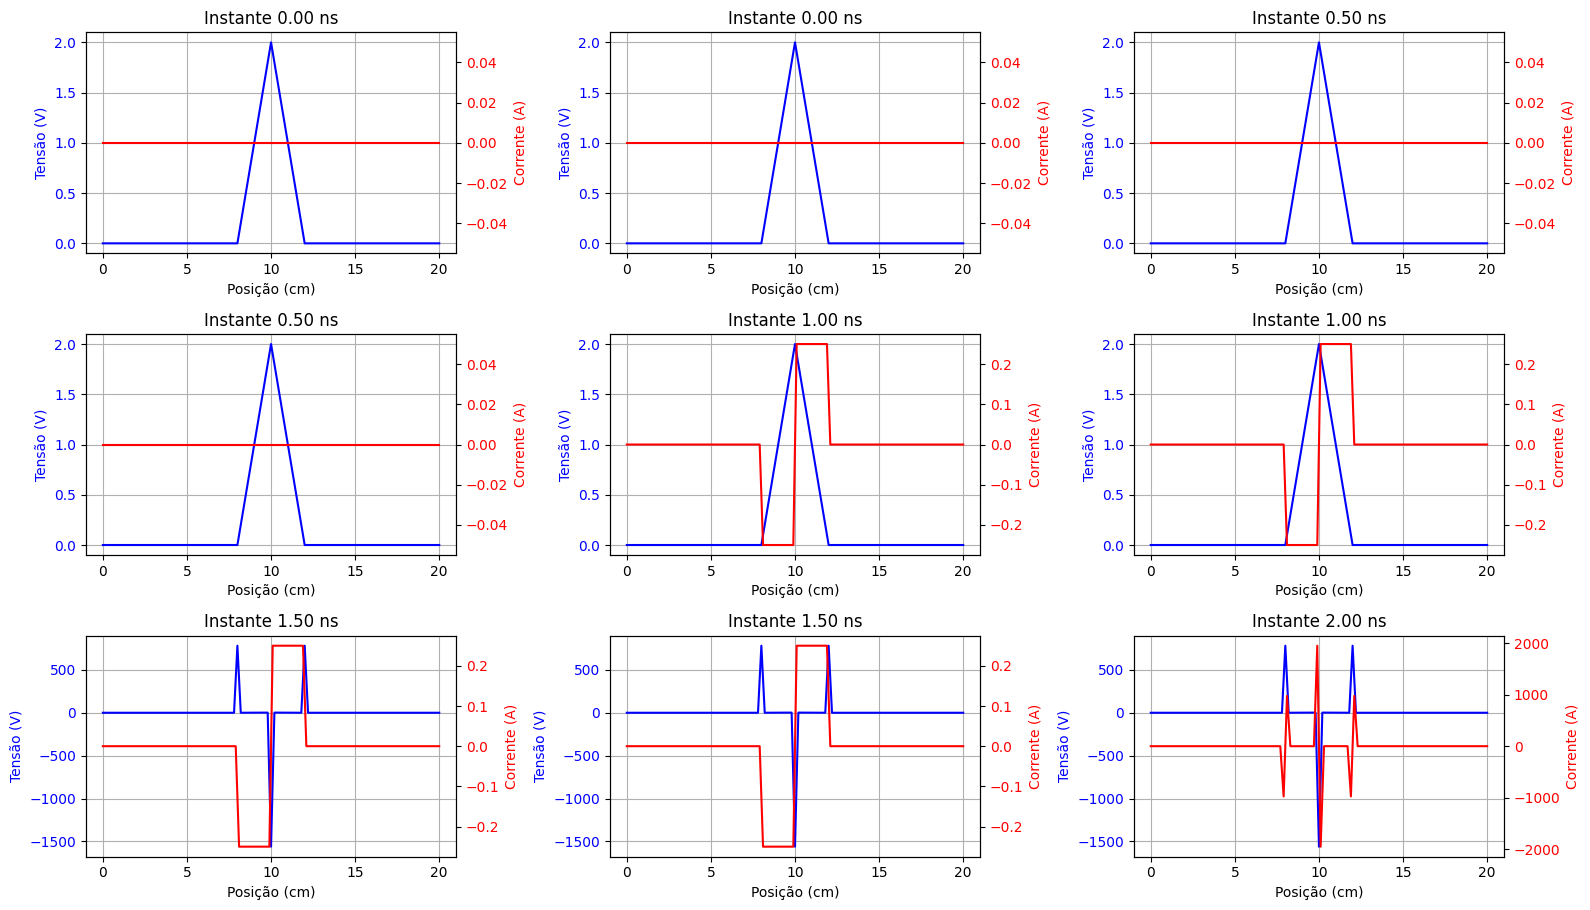

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))

t_list = []
for i in range(9):
    t_list.append(int(i * nt / 9))

for i, ax in enumerate(axes.flatten()):
    ax.plot(x, V[t_list[i], :], color='blue', label='Tensão (V)')
    ax.set_title(f'Instante {t_list[i] * dt * 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (cm)')
    ax.set_ylabel('Tensão (V)', color='blue')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.plot(x, I[t_list[i], :], color='red', label='Corrente (A)')
    ax2.set_ylabel('Corrente (A)', color='red')
    ax2.tick_params(axis='y', labelcolor='r')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()

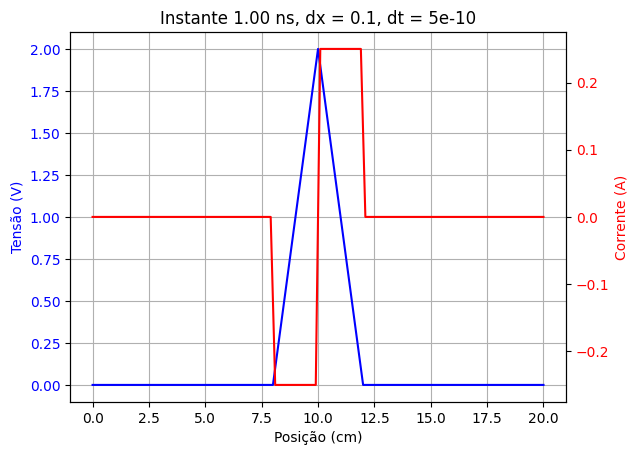

In [82]:
# plota somente um snapshot: nx / 4
time_index = int(4 * nt / 9)

# Create figure and first axis
fig, ax1 = plt.subplots()

ax1.plot(x, V[time_index, :], color='blue', label='Tensão (V)')
ax1.set_title(f'Instante {time_index * dt * 1e9:.2f} ns, dx = {dx}, dt = {dt}')      # Set a title for each subplot
ax1.set_xlabel('Posição (cm)')
ax1.set_ylabel('Tensão (V)', color='blue')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, I[time_index, :], color='red', label='Corrente (A)')
ax2.set_ylabel('Corrente (A)', color='red')
ax2.tick_params(axis='y', labelcolor='r')

plt.show()